# Data Challenge : Lynred data

---

In [4]:
import pandas as pd
import numpy as np
import cv2
import glob, os
import matplotlib.pyplot as plt

---

## Loading the data

In [ ]:
def load_images(folder='train',type='VGA',sequence='sequence_1', dyn='low dyn with columns 1'):
    """
    function that load a folder of images

    args : 
    folder : folder type
    type : type of the frame (HD, VGA, SXGA)
    sequence : sequence_1, sequence_2, sequence_3
    dyn : low dyn with columns 1, low dyn with columns 2, low dyn with columns 3

    return :
    list of the images of the folder
    """
    images = []
    for image in glob.glob(folder+'/'+type+'/'+sequence+'/'+dyn+'/*'):
        img = cv2.imread(image)
        images.append(img)
    return images

In [20]:
def load_dataset(folder='train'):
    """
    function that load all the data set

    return : 
    dict : with every concept 
    list : with every image 
    """
    types = ['HD', 'SXGA', 'VGA']
    sequences = ['sequence_1', 'sequence_2', 'sequence_3']
    dynamics = [
        'high_dyn',
        'low dyn',
        'low dyn with columns 1',
        'low dyn with columns 2',
        'low dyn with columns 3'
    ]

    dataset_dict = {}
    all_images_list = []

    for t in types:
        dataset_dict[t] = {}
        for seq in sequences:
            dataset_dict[t][seq] = {}
            for dyn in dynamics:
                images_in_folder = load_images(
                    folder=folder, 
                    type_frame=t, 
                    sequence=seq, 
                    dyn=dyn
                )
                dataset_dict[t][seq][dyn] = images_in_folder
                all_images_list.extend(images_in_folder)

    return dataset_dict, all_images_list

In [15]:
minus_datetrain = load_images()

## Explore the Dataset

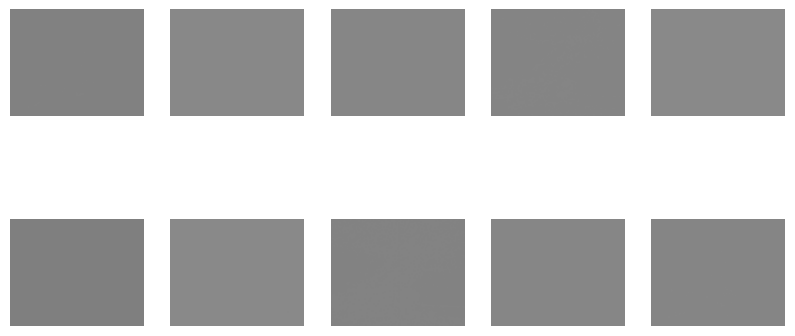

In [18]:
fig, axes = plt.subplots(2, 5, figsize=(10,5))

for i in range(0,2,1):
    for j in range(0,5,1):
        index_image = i * 5 + j 
        axes[i, j].imshow(minus_datetrain[index_image])
        axes[i, j].axis('off')